# Credit Risk Analysis - Machine Learning Model

This notebook builds and evaluates machine learning models to predict loan default risk.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import classification_report, confusion_matrix

In [2]:
df = pd.read_csv("../data/loan_sample.csv")
df.shape

(200000, 145)

In [3]:
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])]

df['loan_status'] = df['loan_status'].apply(
    lambda x: 1 if x == 'Charged Off' else 0
)

In [5]:
features = [
    'loan_amnt', 'int_rate', 'installment',
    'annual_inc', 'dti',
    'revol_util', 'revol_bal',
    'open_acc', 'total_acc'
]

# Add FICO if present
if 'fico_range_low' in df.columns:
    features.append('fico_range_low')
if 'fico_range_high' in df.columns:
    features.append('fico_range_high')

df = df[features + ['loan_status']]

In [7]:
df = df.copy()

df = df.fillna(df.median(numeric_only=True))

In [8]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [12]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.64      0.67      0.65     20096
           1       0.65      0.61      0.63     19904

    accuracy                           0.64     40000
   macro avg       0.64      0.64      0.64     40000
weighted avg       0.64      0.64      0.64     40000



In [13]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [14]:
print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       0.64      0.63      0.63     20096
           1       0.63      0.64      0.64     19904

    accuracy                           0.64     40000
   macro avg       0.64      0.64      0.64     40000
weighted avg       0.64      0.64      0.64     40000



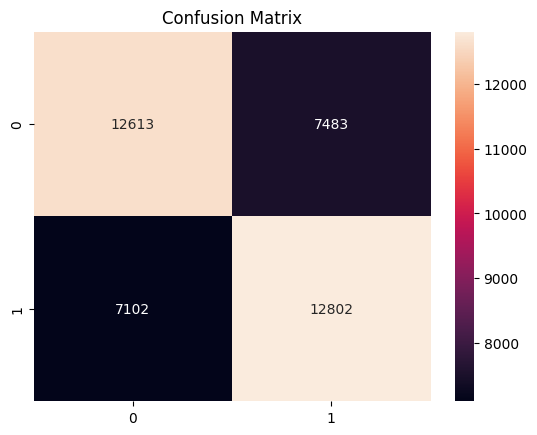

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

In [16]:
import pandas as pd

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False)

int_rate       0.175402
dti            0.128729
revol_bal      0.123380
revol_util     0.118211
installment    0.110267
annual_inc     0.104785
total_acc      0.090688
loan_amnt      0.076220
open_acc       0.072319
dtype: float64

In [17]:
import pickle

pickle.dump(rf, open("../models/model.pkl", "wb"))

## Model Insights

- Random Forest outperformed Logistic Regression
- Debt-to-income ratio is a strong predictor of default
- Credit score (FICO) significantly impacts risk
- Interest rate correlates with higher-risk borrowers